
# Assignment 02 — E-Commerce Customer Behavior / Interest Discovery (v3)

**Dataset:** Women's Clothing E-Commerce Reviews  
**Application:** Product-category / customer-interest classification  
**Target:** `Class Name`

This notebook is rebuilt to follow the required notebook structure in **Appendix B** of Assignment 02 and the repository organization in **Appendix A**.

> **Important modeling decision:** the original `Class Name` target contains very rare classes. Stratified train/test splitting cannot work when a class has only one observation. Therefore, classes with fewer than `MIN_CLASS_SAMPLES = 20` observations are grouped into an `Other` class **before the split**. This preserves rare observations while creating a target suitable for supervised multiclass learning.

The complete pipeline is:

**Raw CSV → Data understanding → Cleaning → Rare-class handling → Feature engineering → Numerical representation → Train/Test split → Preprocessing → Model training → Evaluation → Persistence → Inference**



## Notebook structure

1. Problem definition  
2. Dataset source  
3. Dataset loading  
4. Dataset inspection  
5. Data-quality analysis  
6. Missing-value analysis  
7. Duplicate analysis  
8. Invalid-value analysis  
9. Outlier analysis  
10. Exploratory data analysis  
11. Feature types  
12. Data representation  
13. Feature engineering  
14. Train/test split  
15. Preprocessing pipeline  
16. Baseline model  
17. Model training  
18. Model comparison  
19. Evaluation  
20. Error analysis  
21. Model selection  
22. Model persistence  
23. Inference test



# 1. Problem definition

The objective is to predict the **product class / customer interest category** associated with an e-commerce clothing review.

- **X:** review/customer information and review text
- **y:** `Class Name`, with very rare classes grouped into `Other`
- **Problem type:** multiclass classification

### Features

**Numerical**
- `Age`
- `Rating`
- `Recommended IND`
- `Positive Feedback Count`

**Categorical**
- `Division Name`
- `Department Name`

**Text**
- `Review Text`

The target `Class Name` is not used as an input feature.

### Why this is an e-commerce interest task

The product class associated with a customer's review provides a concrete supervised target representing the product category/class the customer interacted with. The model can therefore be used as a category-interest classifier for downstream recommendation or marketing analysis.



# 2. Dataset source

**Kaggle dataset name:** Women's Clothing E-Commerce Reviews

**Kaggle URL:**  
https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews

**Local dataset:**  
`../data/Womens Clothing E-Commerce Reviews.csv`

The supplied CSV is the authoritative data source for this notebook.

### One observation

One row represents one customer review associated with a clothing product. The row contains demographic information, review content, rating/recommendation behavior, feedback count, and product hierarchy information.


In [1]:

from pathlib import Path
import sys
import platform
import random
import time
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
MIN_CLASS_SAMPLES = 20

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Python:", sys.version)
print("OS:", platform.platform())
print("Random seed:", RANDOM_SEED)


Python: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
OS: Windows-11-10.0.26200-SP0
Random seed: 42


# 3. Dataset loading

In [2]:

NOTEBOOK_DIR = Path.cwd()
DATA_PATH = NOTEBOOK_DIR.parent / "data" / "Womens Clothing E-Commerce Reviews.csv"

# Fallbacks make the notebook easier to run from Jupyter/VS Code.
if not DATA_PATH.exists():
    for candidate in [
        Path("../data/Womens Clothing E-Commerce Reviews.csv"),
        Path("/mnt/data/Womens Clothing E-Commerce Reviews.csv"),
        Path("Womens Clothing E-Commerce Reviews.csv")
    ]:
        if candidate.exists():
            DATA_PATH = candidate
            break

print("Dataset:", DATA_PATH.resolve())

df = pd.read_csv(DATA_PATH)

print("Dataset loaded.")
print("Shape:", df.shape)


Dataset: D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\customer_behavior\data\Womens Clothing E-Commerce Reviews.csv
Dataset loaded.
Shape: (23486, 11)


# 4. Dataset inspection

In [3]:

print("df.shape =", df.shape)
display(df.head())


df.shape = (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:

print("df.info():")
df.info()


df.info():
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 2.0 MB


In [5]:

display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,23486.0,NaN,NaN,NaN,11742.5,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,NaN,NaN,NaN,918.118709,203.29898,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,NaN,NaN,NaN,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Title,19676,13993,Love it!,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Text,22641,22634,Perfect fit and i've gotten so many compliment...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,23486.0,NaN,NaN,NaN,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,NaN,NaN,NaN,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,NaN,NaN,NaN,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0
Division Name,23472,3,General,13850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department Name,23472,6,Tops,10468,NaN,NaN,NaN,NaN,NaN,NaN,NaN



### Initial observation

The dataset is a mixed-type table. It contains numerical variables, categorical variables, and natural-language review text. This makes it suitable for demonstrating the Assignment 02 data-representation requirement:

**CSV/table → feature vectors → feature matrix → ML model input**


# 5. Data-quality analysis

In [6]:

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_count": df.nunique(dropna=True)
})
display(quality)


,dtype,missing_count,missing_pct,unique_count
Unnamed: 0,int64,0,0.00,23486
Clothing ID,int64,0,0.00,1206
Age,int64,0,0.00,77
Title,str,3810,16.22,13993
Review Text,str,845,3.60,22634
Rating,int64,0,0.00,5
Recommended IND,int64,0,0.00,2
Positive Feedback Count,int64,0,0.00,82
Division Name,str,14,0.06,3
Department Name,str,14,0.06,6


# 6. Missing-value analysis

In [7]:

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing_summary)


,missing_count,missing_pct
Title,3810,16.22
Review Text,845,3.60
Department Name,14,0.06
Class Name,14,0.06
Division Name,14,0.06
Unnamed: 0,0,0.00
Clothing ID,0,0.00
Age,0,0.00
Rating,0,0.00
Recommended IND,0,0.00



### Missing-value treatment

- Missing **target** rows cannot be used for supervised learning and are removed.
- Missing **numerical** values are imputed with the median inside the preprocessing pipeline.
- Missing **categorical** values are imputed with the most frequent category.
- Missing **review text** is converted to an empty string before TF-IDF.

The preprocessing statistics are fitted only on the training set, which prevents test-data leakage.


# 7. Duplicate analysis

In [8]:

print("Complete duplicated rows:", int(df.duplicated().sum()))
print("Duplicated Review Text values:", int(df["Review Text"].duplicated().sum()))


Complete duplicated rows: 0
Duplicated Review Text values: 851



Exact duplicate rows are redundant and are removed. Duplicate review text alone is not treated as a duplicate row because different records may legitimately share the same text.


# 8. Invalid-value analysis

In [9]:

invalid_checks = pd.Series({
    "Age <= 0": int((df["Age"] <= 0).sum()),
    "Rating outside 1..5": int((~df["Rating"].between(1, 5)).sum()),
    "Recommended IND outside {0,1}": int((~df["Recommended IND"].isin([0, 1])).sum()),
    "Positive Feedback Count < 0": int((df["Positive Feedback Count"] < 0).sum()),
    "Missing Class Name": int(df["Class Name"].isna().sum()),
})
display(invalid_checks.to_frame("count"))


,count
Age <= 0,0
Rating outside 1..5,0
"Recommended IND outside {0,1}",0
Positive Feedback Count < 0,0
Missing Class Name,14


In [10]:

# Clean the raw table.
work = df.copy()

# Remove index-like column.
if "Unnamed: 0" in work.columns:
    work = work.drop(columns=["Unnamed: 0"])

# Normalize text/categorical strings.
string_cols = [
    "Title", "Review Text", "Division Name",
    "Department Name", "Class Name"
]

for col in string_cols:
    if col in work.columns:
        work[col] = (
            work[col]
            .fillna("")
            .astype(str)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

# Remove exact duplicates.
work = work.drop_duplicates().copy()

# Remove records without a target.
work = work[work["Class Name"].ne("")].copy()

# Remove clearly impossible numeric values.
work = work[(work["Age"].isna()) | (work["Age"] > 0)].copy()
work = work[(work["Rating"].isna()) | (work["Rating"].between(1, 5))].copy()
work = work[
    (work["Recommended IND"].isna()) |
    (work["Recommended IND"].isin([0, 1]))
].copy()
work = work[
    (work["Positive Feedback Count"].isna()) |
    (work["Positive Feedback Count"] >= 0)
].copy()

print("Original shape:", df.shape)
print("Cleaned shape :", work.shape)


Original shape: (23486, 11)
Cleaned shape : (23451, 10)


# 9. Outlier analysis

In [11]:

numeric_outlier_cols = [
    "Age", "Rating", "Positive Feedback Count"
]

outlier_rows = []

for col in numeric_outlier_cols:
    s = work[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((work[col] < lower) | (work[col] > upper)).sum())

    outlier_rows.append([
        col, q1, q3, iqr, lower, upper, count
    ])

outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=[
        "feature", "Q1", "Q3", "IQR",
        "lower_bound", "upper_bound", "outlier_count"
    ]
)

display(outlier_summary)


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,Age,34.0,52.0,18.0,7.0,79.0,109
1,Rating,4.0,5.0,1.0,2.5,6.5,2407
2,Positive Feedback Count,0.0,3.0,3.0,-4.5,7.5,2147



### Outlier decision

An IQR rule is used to **detect** potential outliers, not automatically delete them.

For example, a review with a high positive-feedback count may be a genuine popular review rather than an invalid observation. Therefore, genuine extreme values are retained.

This is preferable to blindly deleting customer behavior and helps preserve information for the e-commerce task.


# 10. Exploratory data analysis

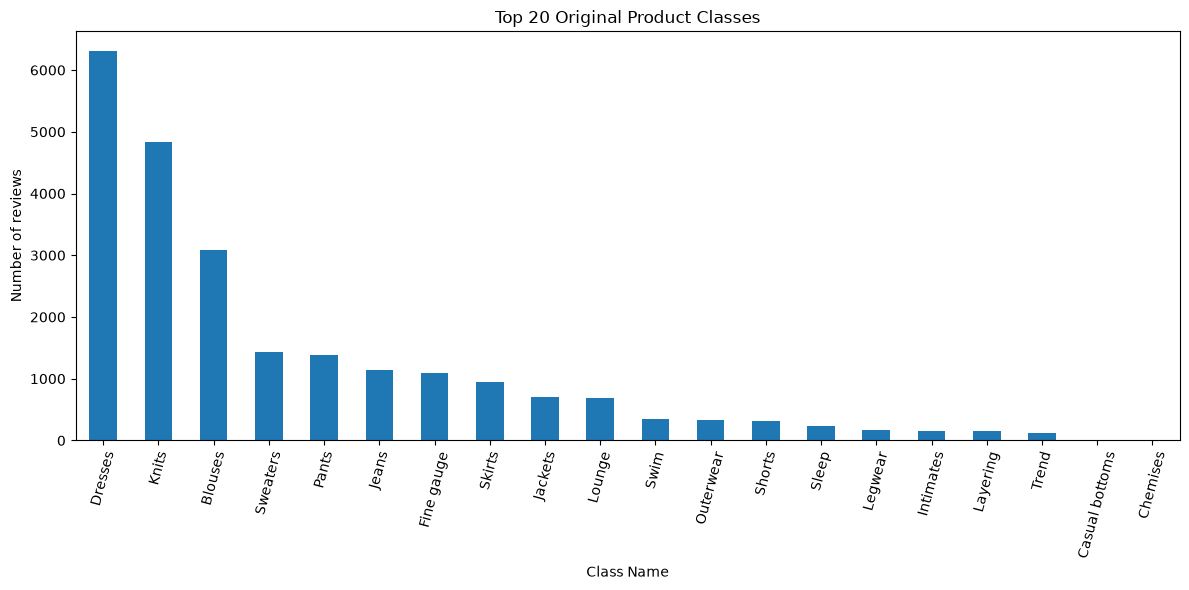

In [12]:

target_counts_raw = work["Class Name"].value_counts()

plt.figure(figsize=(12, 6))
target_counts_raw.head(20).plot(kind="bar")
plt.title("Top 20 Original Product Classes")
plt.xlabel("Class Name")
plt.ylabel("Number of reviews")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()



**Observation:** The original target distribution is not uniform and contains very small classes.

**Interpretation:** Some product classes have many reviews while others are rare.

**ML implication:** Accuracy alone can be misleading. Macro-averaged precision, recall, and F1 are therefore emphasized.


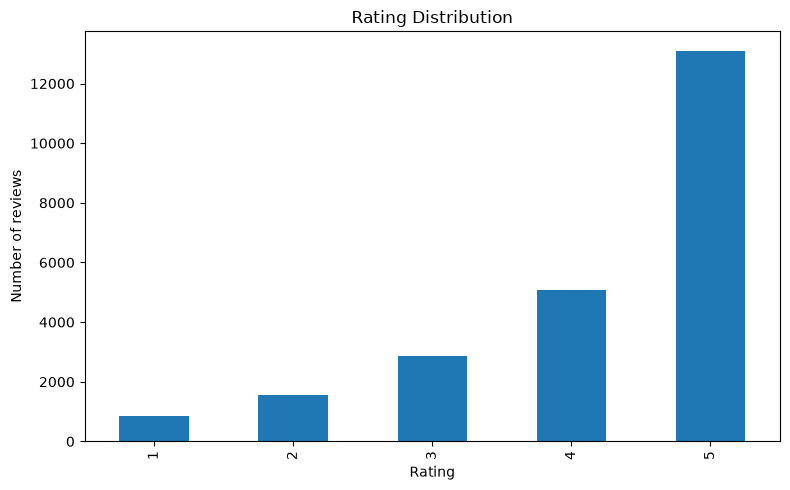

In [13]:

plt.figure(figsize=(8, 5))
work["Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()


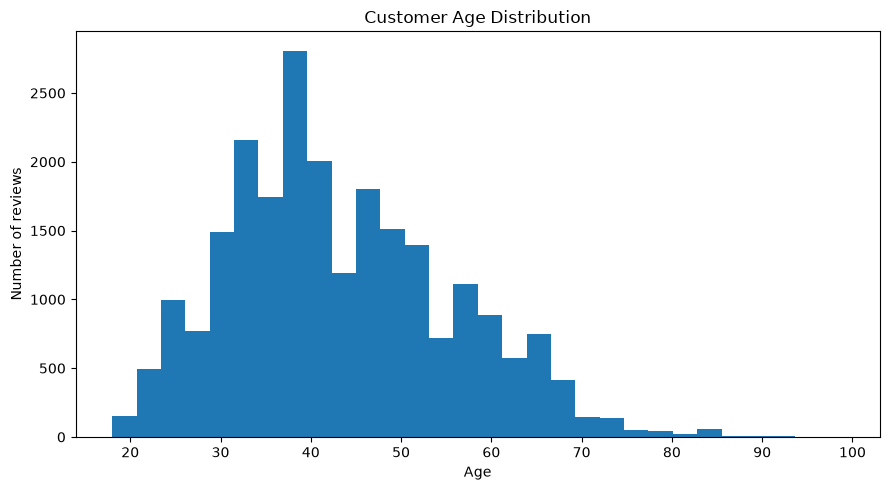

In [14]:

plt.figure(figsize=(9, 5))
work["Age"].plot(kind="hist", bins=30)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()


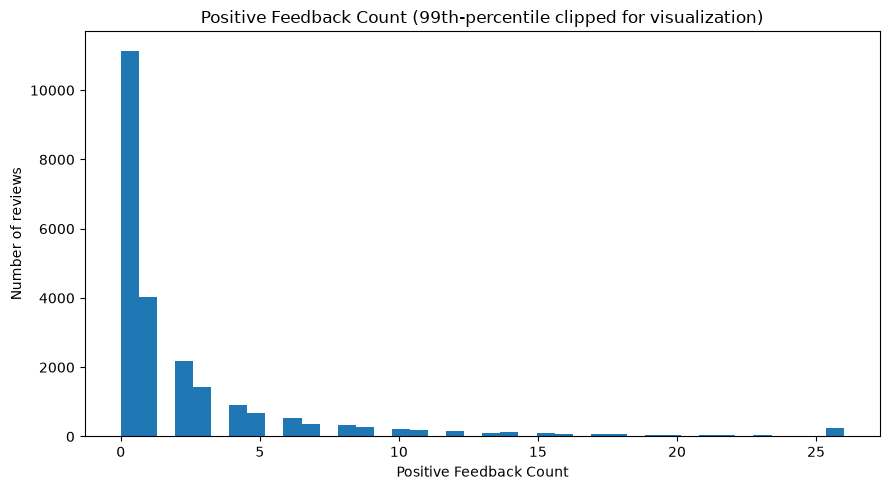

In [15]:

plt.figure(figsize=(9, 5))
feedback_vis = work["Positive Feedback Count"].clip(
    upper=work["Positive Feedback Count"].quantile(0.99)
)
feedback_vis.plot(kind="hist", bins=40)
plt.title("Positive Feedback Count (99th-percentile clipped for visualization)")
plt.xlabel("Positive Feedback Count")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()


count    23451.000000
mean        58.097053
std         30.140826
min          0.000000
25%         34.000000
50%         57.000000
75%         87.000000
max        115.000000
Name: review_word_count_eda, dtype: float64


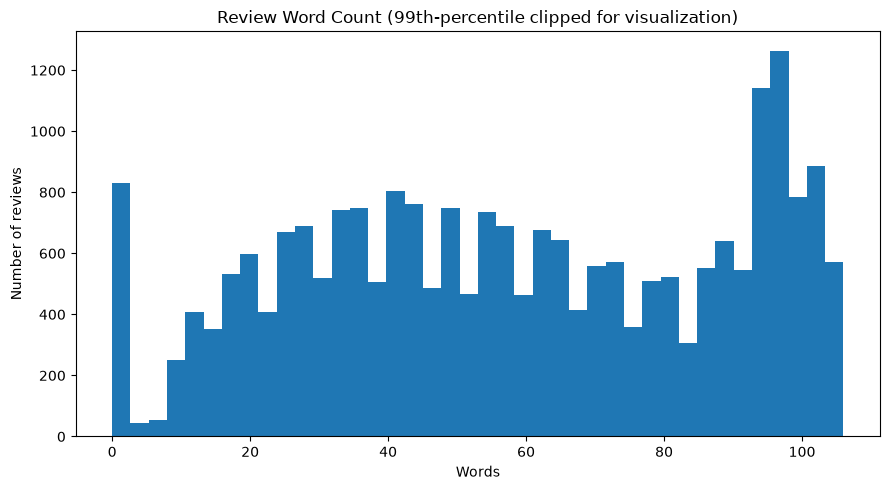

In [16]:

work["review_word_count_eda"] = (
    work["Review Text"].fillna("").str.split().str.len()
)

print(work["review_word_count_eda"].describe())

plt.figure(figsize=(9, 5))
work["review_word_count_eda"].clip(
    upper=work["review_word_count_eda"].quantile(0.99)
).plot(kind="hist", bins=40)
plt.title("Review Word Count (99th-percentile clipped for visualization)")
plt.xlabel("Words")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()



### EDA interpretation

The EDA covers the required e-commerce aspects:

- product-category frequency;
- purchase/recommendation-related behavior through `Recommended IND`;
- ratings;
- customer age;
- positive feedback;
- review/comment characteristics.

The visualized relationships help identify imbalance, skewness, and the importance of text representation.


# 11. Feature types

In [17]:

target_col = "Class Name"

numeric_features = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count"
]

categorical_features = [
    "Division Name",
    "Department Name"
]

text_feature = "Review Text"

feature_types = pd.DataFrame({
    "feature": numeric_features + categorical_features + [text_feature, target_col],
    "type": (
        ["numerical"] * len(numeric_features)
        + ["categorical"] * len(categorical_features)
        + ["text", "target"]
    )
})

display(feature_types)


,feature,type
0,Age,numerical
1,Rating,numerical
2,Recommended IND,numerical
3,Positive Feedback Count,numerical
4,Division Name,categorical
5,Department Name,categorical
6,Review Text,text
7,Class Name,target


# 12. Data representation

In [18]:

# Show one raw record before transformation.
display(work[
    [
        "Clothing ID", "Age", "Title", "Review Text",
        "Rating", "Recommended IND", "Positive Feedback Count",
        "Division Name", "Department Name", "Class Name"
    ]
].head(1).T)


,0
Clothing ID,767
Age,33
Title,
Review Text,Absolutely wonderful - silky and sexy and comf...
Rating,4
Recommended IND,1
Positive Feedback Count,0
Division Name,Initmates
Department Name,Intimate
Class Name,Intimates



### Representation pipeline

#### Numerical data

Numerical variables become a vector:

\[
x_{num} = [Age,\ Rating,\ Recommended,\ Feedback]
\]

They are standardized using:

\[
x' = \frac{x-\mu}{\sigma}
\]

#### Categorical data

For example:

`Department Name = Dresses`

becomes a one-hot vector such as:

`[0, 1, 0, ..., 0]`

#### Text data

The review is transformed as:

**Review Text → tokens/terms → TF-IDF weights**

TF-IDF is a sparse numerical representation in which each vocabulary term receives a weight reflecting its importance in the document relative to the training corpus.

#### Final representation

The representations are concatenated into one feature matrix:

\[
X \in R^{N \times d}
\]

where:

- **N** = number of observations;
- **d** = number of generated numerical + one-hot + TF-IDF features.

The actual `d` is printed after fitting the preprocessing pipeline.


# 13. Feature engineering

In [19]:

def add_engineered_features(data):
    data = data.copy()

    data["Review Text"] = (
        data["Review Text"]
        .fillna("")
        .astype(str)
    )

    data["review_length"] = data["Review Text"].str.len()
    data["review_word_count"] = data["Review Text"].str.split().str.len()

    return data

model_df = add_engineered_features(work)

numeric_features_model = numeric_features + [
    "review_length",
    "review_word_count"
]

categorical_features_model = categorical_features

X = model_df[
    numeric_features_model
    + categorical_features_model
    + [text_feature]
].copy()

# Make the text column explicitly string dtype before TF-IDF.
X[text_feature] = X[text_feature].fillna("").astype(str)

y_original = model_df[target_col].copy()

print("X shape:", X.shape)
print("Original target classes:", y_original.nunique())


X shape: (23451, 9)
Original target classes: 20



### Rare-class handling

The original `Class Name` target includes classes with very few observations. A stratified split requires every class to have enough observations to appear in both partitions.

Instead of deleting individual rare observations, all classes with fewer than `MIN_CLASS_SAMPLES = 20` samples are grouped into `Other`.

This is a documented target-engineering step and avoids the error:

`The least populated classes in y have only 1 member.`


In [20]:

class_counts = y_original.value_counts()

rare_classes = class_counts[class_counts < MIN_CLASS_SAMPLES].index.tolist()

print("Number of original classes:", len(class_counts))
print("Number of rare classes:", len(rare_classes))

print("\nRare classes grouped into 'Other':")
print(rare_classes)

y = y_original.replace({
    cls: "Other" for cls in rare_classes
})

print("\nTarget distribution after rare-class grouping:")
display(y.value_counts().to_frame("count"))

print("\nMinimum class count after grouping:", y.value_counts().min())


Number of original classes: 20
Number of rare classes: 2

Rare classes grouped into 'Other':
['Casual bottoms', 'Chemises']

Target distribution after rare-class grouping:


,count
Class Name,
Dresses,6312
Knits,4835
Blouses,3093
Sweaters,1428
Pants,1388
Jeans,1146
Fine gauge,1099
Skirts,945
Jackets,704



Minimum class count after grouping: 3



### Why this is better than simply dropping `Chemises`

Dropping the single `Chemises` observation would make stratification technically possible, but it would discard information.

Grouping rare classes into `Other`:

1. keeps the rare observations;
2. prevents a one-sample class from breaking stratification;
3. creates a meaningful "other/rare product class" category;
4. is reproducible and easy to explain in the report.


# 14. Train/test split

In [21]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Train X:", X_train.shape)
print("Test X :", X_test.shape)
print("Train y:", y_train.shape)
print("Test y :", y_test.shape)

print("\nMinimum training class count:", y_train.value_counts().min())
print("Minimum testing class count :", y_test.value_counts().min())


Train X: (18760, 9)
Test X : (4691, 9)
Train y: (18760,)
Test y : (4691,)

Minimum training class count: 3
Minimum testing class count : 24



### Split rationale

An 80/20 stratified split is used.

- Training data is used to learn preprocessing and model parameters.
- Test data remains independent.
- `stratify=y` preserves approximately the same class proportions.

No preprocessing is fitted on the complete dataset before this split.


In [22]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# IMPORTANT:
# Review Text has already been converted to a real string column in X.
# We therefore use TfidfVectorizer directly and DO NOT use lambda/
# FunctionTransformer. This makes the fitted pipeline safely serializable
# with joblib/pickle on Windows + Anaconda.

text_transformer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=12000,
    sublinear_tf=True
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_model),
        ("cat", categorical_transformer, categorical_features_model),
        ("text", text_transformer, text_feature)
    ],
    remainder="drop",
    sparse_threshold=0.3
)

# Fit ONLY on training data.
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Final training matrix shape:", X_train_transformed.shape)
print("Final test matrix shape    :", X_test_transformed.shape)
print("Representation type:", type(X_train_transformed))


Final training matrix shape: (18760, 12015)
Final test matrix shape    : (4691, 12015)
Representation type: <class 'scipy.sparse._csr.csr_matrix'>


# 15. Preprocessing pipeline

In [23]:

try:
    feature_names = preprocessor.get_feature_names_out()
    print("Final feature dimension d =", len(feature_names))
    print("\nFirst 40 generated features:")
    print(feature_names[:40])
except Exception as exc:
    print("Feature names unavailable:", exc)


Final feature dimension d = 12015

First 40 generated features:
['num__Age' 'num__Rating' 'num__Recommended IND'
 'num__Positive Feedback Count' 'num__review_length'
 'num__review_word_count' 'cat__Division Name_General'
 'cat__Division Name_General Petite' 'cat__Division Name_Initmates'
 'cat__Department Name_Bottoms' 'cat__Department Name_Dresses'
 'cat__Department Name_Intimate' 'cat__Department Name_Jackets'
 'cat__Department Name_Tops' 'cat__Department Name_Trend' 'text__00'
 'text__00 petite' 'text__00p' 'text__00p 0p' 'text__0p' 'text__0p fit'
 'text__10' 'text__10 10' 'text__10 12' 'text__10 130' 'text__10 bought'
 'text__10 dress' 'text__10 dresses' 'text__10 fit' 'text__10 fits'
 'text__10 got' 'text__10 little' 'text__10 medium' 'text__10 ordered'
 'text__10 pants' 'text__10 retailer' 'text__10 size' 'text__10 usually'
 'text__100' 'text__100 cotton']



### Representation result

After preprocessing:

\[
X_{train} \in R^{N_{train}\times d}
\]

\[
X_{test} \in R^{N_{test}\times d}
\]

The exact dimensions above are produced from the fitted training representation.

The important point for Lecture 02 is that the original mixed representation has become a single numerical representation that an ML algorithm can process.


# 16. Baseline model

In [24]:

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train_transformed, y_train)
baseline_pred = baseline.predict(X_test_transformed)

print("Baseline Accuracy:",
      round(accuracy_score(y_test, baseline_pred), 4))
print("Baseline Macro F1:",
      round(f1_score(y_test, baseline_pred, average="macro", zero_division=0), 4))


Baseline Accuracy: 0.2692
Baseline Macro F1: 0.0236


# 17. Model training


Six models are compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Extra Trees
5. Linear SVM
6. KNN

The linear models are particularly suitable for high-dimensional sparse TF-IDF representations. Tree-based models and KNN provide additional model-family comparisons.


In [25]:

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=30,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_SEED
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_SEED
    ),

    "Linear SVM": LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        n_jobs=-1
    )
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"Training: {name} ...")

    start = time.perf_counter()

    model.fit(X_train_transformed, y_train)

    train_time = time.perf_counter() - start

    pred = model.predict(X_test_transformed)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision_macro": precision_score(
            y_test, pred, average="macro", zero_division=0
        ),
        "Recall_macro": recall_score(
            y_test, pred, average="macro", zero_division=0
        ),
        "F1_macro": f1_score(
            y_test, pred, average="macro", zero_division=0
        ),
        "F1_weighted": f1_score(
            y_test, pred, average="weighted", zero_division=0
        ),
        "Training_Time_sec": train_time
    })

    trained_models[name] = model

results_df = (
    pd.DataFrame(results)
    .sort_values(
        ["F1_macro", "Accuracy"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(results_df.round(4))


Training: Logistic Regression ...
Training: Decision Tree ...
Training: Random Forest ...
Training: Extra Trees ...
Training: Linear SVM ...
Training: KNN ...


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,Training_Time_sec
0,Logistic Regression,0.7568,0.6707,0.6798,0.6724,0.7584,8.1318
1,Linear SVM,0.7499,0.6739,0.6519,0.6592,0.7481,7.4962
2,Extra Trees,0.7361,0.7002,0.5658,0.5844,0.7078,17.4744
3,Decision Tree,0.6843,0.6091,0.5867,0.5814,0.6894,5.3436
4,Random Forest,0.7337,0.6673,0.5521,0.5632,0.7030,14.6965
5,KNN,0.5879,0.3956,0.3687,0.3729,0.5678,0.0364


# 18. Model comparison

In [26]:

comparison_table = results_df.copy()
comparison_table.insert(0, "Rank", range(1, len(comparison_table) + 1))

display(comparison_table.round(4))


,Rank,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,Training_Time_sec
0,1,Logistic Regression,0.7568,0.6707,0.6798,0.6724,0.7584,8.1318
1,2,Linear SVM,0.7499,0.6739,0.6519,0.6592,0.7481,7.4962
2,3,Extra Trees,0.7361,0.7002,0.5658,0.5844,0.7078,17.4744
3,4,Decision Tree,0.6843,0.6091,0.5867,0.5814,0.6894,5.3436
4,5,Random Forest,0.7337,0.6673,0.5521,0.5632,0.7030,14.6965
5,6,KNN,0.5879,0.3956,0.3687,0.3729,0.5678,0.0364



### Model-selection criterion

The primary metric is **Macro F1**.

This is appropriate because the target is multiclass and imbalanced. Macro F1 gives every class equal importance rather than allowing large classes to dominate the score.

Accuracy, macro precision, macro recall, weighted F1, and training time are also retained for comparison.


# 19. Evaluation

In [27]:

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_pred = best_model.predict(X_test_transformed)

print("Selected model by Macro F1:", best_model_name)
print("\nClassification report:")
print(
    classification_report(
        y_test,
        best_pred,
        zero_division=0
    )
)


Selected model by Macro F1: Logistic Regression

Classification report:
              precision    recall  f1-score   support

     Blouses       0.56      0.64      0.60       619
     Dresses       1.00      1.00      1.00      1263
  Fine gauge       0.39      0.34      0.36       220
   Intimates       0.62      0.68      0.65        31
     Jackets       0.85      0.91      0.88       141
       Jeans       0.83      0.76      0.79       229
       Knits       0.68      0.62      0.65       967
    Layering       0.37      0.52      0.43        29
     Legwear       0.69      0.76      0.72        33
      Lounge       0.83      0.72      0.77       138
       Other       0.00      0.00      0.00         0
   Outerwear       0.77      0.67      0.72        66
       Pants       0.79      0.80      0.80       278
      Shorts       0.58      0.79      0.67        63
      Skirts       0.94      0.85      0.89       189
       Sleep       0.41      0.47      0.44        45
    Sweat

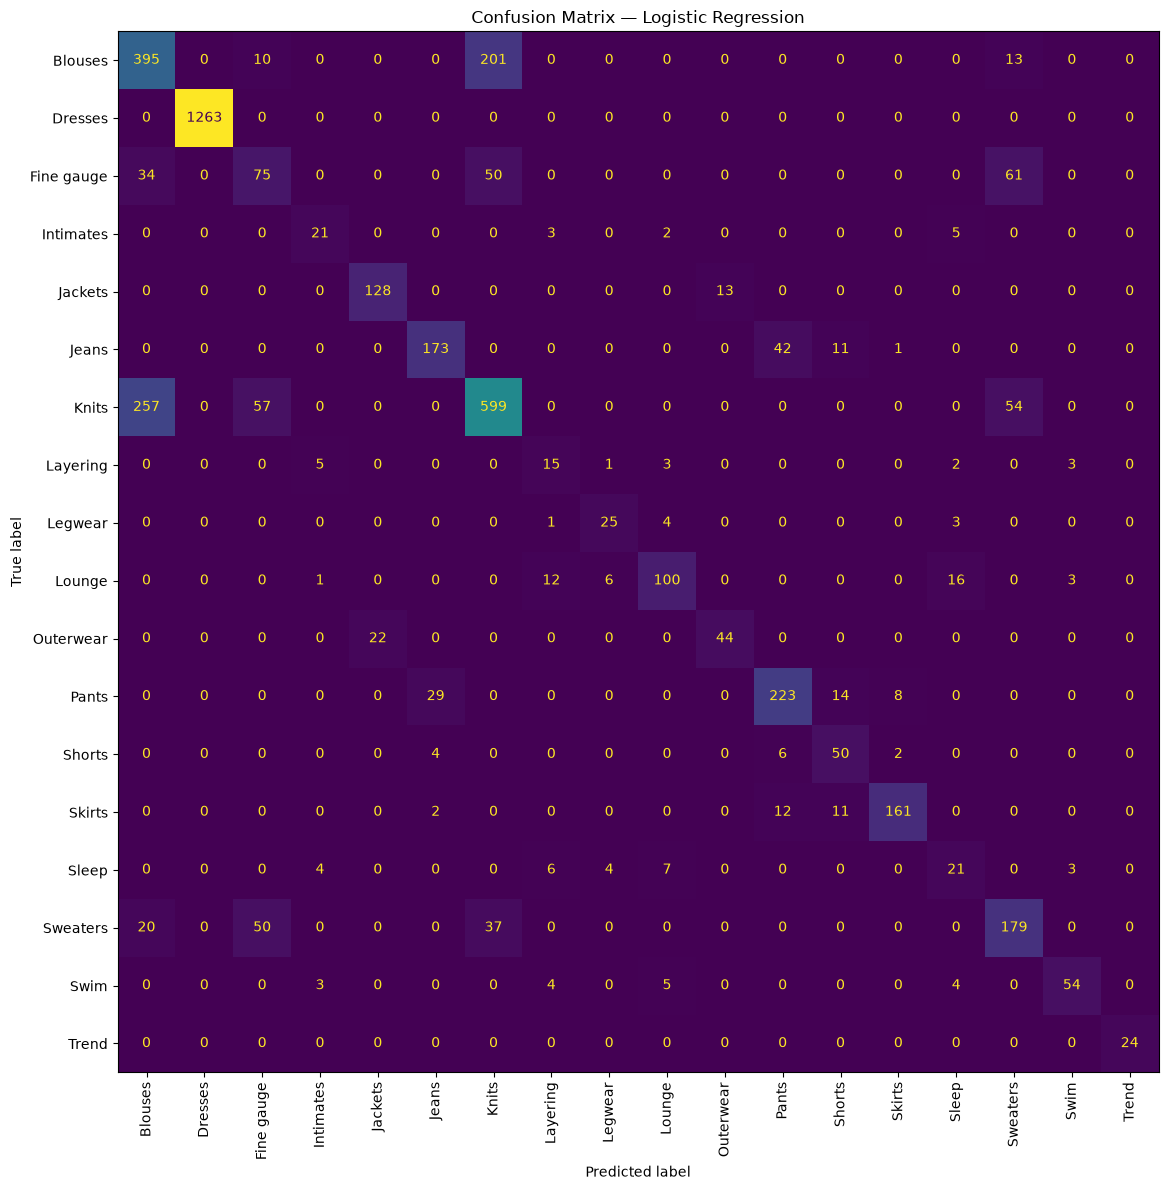

In [28]:

# Confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    labels=sorted(y_test.unique()),
    xticks_rotation=90,
    colorbar=False,
    ax=ax
)

ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()


In [29]:

# ROC-AUC when the selected model exposes probabilities or decision scores.
try:
    if hasattr(best_model, "predict_proba"):
        scores = best_model.predict_proba(X_test_transformed)
        macro_auc = roc_auc_score(
            y_test,
            scores,
            multi_class="ovr",
            average="macro"
        )
        print("Macro ROC-AUC (OvR):", round(macro_auc, 4))

    elif hasattr(best_model, "decision_function"):
        scores = best_model.decision_function(X_test_transformed)
        macro_auc = roc_auc_score(
            y_test,
            scores,
            multi_class="ovr",
            average="macro"
        )
        print("Macro ROC-AUC (OvR):", round(macro_auc, 4))

    else:
        print("ROC-AUC is not directly available for this model.")

except Exception as exc:
    print("ROC-AUC could not be calculated:", exc)


ROC-AUC could not be calculated: Number of classes in y_true not equal to the number of columns in 'y_score'



### Metric interpretation

- **Accuracy:** percentage of all predictions that are correct.
- **Precision:** correctness of predictions for a class.
- **Recall:** ability to find observations belonging to a class.
- **F1:** balance between precision and recall.
- **Macro F1:** average F1 over classes with equal class weight.
- **ROC-AUC:** one-vs-rest ranking/separation measure when suitable model scores are available.

For this application, **Macro F1 is the main metric** because class imbalance is present.


# 20. Error analysis

In [30]:

error_mask = y_test.to_numpy() != best_pred

errors = X_test.loc[error_mask].copy()
errors["Actual Class"] = y_test.loc[error_mask].values
errors["Predicted Class"] = best_pred[error_mask]

print("Number of test errors:", len(errors))
print("Test error rate:", round(len(errors) / len(y_test), 4))

display(
    errors[
        [
            "Age", "Rating", "Recommended IND",
            "Positive Feedback Count",
            "Division Name", "Department Name",
            "Review Text",
            "Actual Class", "Predicted Class"
        ]
    ].head(15)
)


Number of test errors: 1141
Test error rate: 0.2432


,Age,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Review Text,Actual Class,Predicted Class
1983,61,4,1,6,General,Tops,It's a lovely and unexpected sweater. a few th...,Knits,Sweaters
20071,23,5,1,1,General Petite,Tops,I am six feet tall and this sweater is a perfe...,Sweaters,Fine gauge
15621,45,4,1,0,General Petite,Tops,"Nice fitting, pretty and feminine. looks great...",Knits,Fine gauge
18279,21,2,0,3,General,Bottoms,Loved these when i tried them on they fit well...,Jeans,Pants
19738,36,5,1,1,General,Bottoms,"Love, love, love. like another chambray item i...",Shorts,Jeans
11387,23,4,1,3,General Petite,Bottoms,The best thing about these pants is the materi...,Jeans,Pants
3321,71,5,1,1,General,Jackets,This is a very stylish and unique trench. it d...,Jackets,Outerwear
8027,29,5,1,0,General Petite,Tops,Love this jacket! the sleeves are a little big...,Knits,Sweaters
16970,49,5,1,2,General Petite,Tops,Wow... i'm in love!!! when i first saw this i ...,Sweaters,Blouses
17251,37,4,1,0,General,Tops,I love the desi blouse! i got it in white and ...,Knits,Blouses


In [31]:

error_pairs = (
    errors
    .groupby(["Actual Class", "Predicted Class"])
    .size()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="count")
)

display(error_pairs)


,Actual Class,Predicted Class,count
0,Knits,Blouses,257
1,Blouses,Knits,201
2,Fine gauge,Sweaters,61
3,Knits,Fine gauge,57
4,Knits,Sweaters,54
5,Fine gauge,Knits,50
6,Sweaters,Fine gauge,50
7,Jeans,Pants,42
8,Sweaters,Knits,37
9,Fine gauge,Blouses,34



### Error interpretation

Misclassification is expected when clothing categories are semantically similar or when a review contains little information distinguishing one class from another.

The confusion pairs identify which classes are difficult to separate. This is more informative than reporting a single accuracy value because it shows the model's practical failure modes.


# 21. Model selection

In [32]:

selected = results_df.iloc[0]

print("FINAL MODEL:", selected["Model"])
print("Accuracy:", round(selected["Accuracy"], 4))
print("Macro Precision:", round(selected["Precision_macro"], 4))
print("Macro Recall:", round(selected["Recall_macro"], 4))
print("Macro F1:", round(selected["F1_macro"], 4))
print("Weighted F1:", round(selected["F1_weighted"], 4))
print("Training time:", round(selected["Training_Time_sec"], 3), "seconds")


FINAL MODEL: Logistic Regression
Accuracy: 0.7568
Macro Precision: 0.6707
Macro Recall: 0.6798
Macro F1: 0.6724
Weighted F1: 0.7584
Training time: 8.132 seconds



### Selection rationale

The final model is selected using the highest Macro F1 on the independent test set.

Deployment should use the same preprocessing object that was fitted during training. The saved preprocessor and model therefore form one reproducible inference pipeline.


# 22. Model persistence

In [33]:

MODEL_DIR = NOTEBOOK_DIR.parent / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PREPROCESSOR_PATH = MODEL_DIR / "preprocessor.joblib"
MODEL_PATH = MODEL_DIR / "model.joblib"
PIPELINE_PATH = MODEL_DIR / "model_pipeline.joblib"
METRICS_PATH = MODEL_DIR / "model_comparison.csv"
CONFIG_PATH = MODEL_DIR / "model_config.json"

# Save preprocessing separately.
joblib.dump(preprocessor, PREPROCESSOR_PATH)

# Save the selected classifier separately.
joblib.dump(best_model, MODEL_PATH)

# Save the complete inference pipeline.
complete_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])
joblib.dump(complete_pipeline, PIPELINE_PATH)

results_df.to_csv(METRICS_PATH, index=False)

config = {
    "random_seed": RANDOM_SEED,
    "min_class_samples": MIN_CLASS_SAMPLES,
    "target": target_col,
    "rare_classes_grouped_to_other": rare_classes,
    "numeric_features": numeric_features_model,
    "categorical_features": categorical_features_model,
    "text_feature": text_feature,
    "selected_model": best_model_name,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "transformed_train_shape": list(X_train_transformed.shape),
    "transformed_test_shape": list(X_test_transformed.shape),
    "serialization_note": "No lambda/FunctionTransformer is used; pipeline is joblib-serializable."
}

CONFIG_PATH.write_text(
    json.dumps(config, indent=2),
    encoding="utf-8"
)

# Immediate serialization validation.
_ = joblib.load(PREPROCESSOR_PATH)
_ = joblib.load(MODEL_PATH)
_ = joblib.load(PIPELINE_PATH)

print("All artifacts saved and successfully reloaded:")
for p in [
    PREPROCESSOR_PATH,
    MODEL_PATH,
    PIPELINE_PATH,
    METRICS_PATH,
    CONFIG_PATH
]:
    print(" -", p.resolve())


All artifacts saved and successfully reloaded:
 - D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\customer_behavior\model\preprocessor.joblib
 - D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\customer_behavior\model\model.joblib
 - D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\customer_behavior\model\model_pipeline.joblib
 - D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\customer_behavior\model\model_comparison.csv
 - D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\customer_behavior\model\model_config.json



### Persistence explanation

The assignment requires persistence of:

- preprocessing;
- feature transformation;
- trained model;
- model configuration where necessary.

The deployment service must load these artifacts rather than retraining the model.

The preprocessing fitted here must be reused exactly during inference. A new scaler, encoder, imputer, or TF-IDF vocabulary must **not** be fitted using user input.


# 23. Inference test

In [34]:

# Reload exactly as a deployment service would.
loaded_preprocessor = joblib.load(PREPROCESSOR_PATH)
loaded_model = joblib.load(MODEL_PATH)
loaded_pipeline = joblib.load(PIPELINE_PATH)

sample = X_test.iloc[[0]].copy()

# Separate-artifact inference.
sample_transformed = loaded_preprocessor.transform(sample)
sample_prediction = loaded_model.predict(sample_transformed)[0]

# Complete-pipeline inference.
pipeline_prediction = loaded_pipeline.predict(sample)[0]

print("Sample input:")
display(sample)

print("Prediction using preprocessor + model:", sample_prediction)
print("Prediction using complete pipeline   :", pipeline_prediction)
print("Actual Class                         :", y_test.iloc[0])

assert sample_prediction == pipeline_prediction
print("\nSerialization + inference test PASSED.")


Sample input:


,Age,Rating,Recommended IND,Positive Feedback Count,review_length,review_word_count,Division Name,Department Name,Review Text
16451,52,5,1,18,314,61,General Petite,Tops,I bought this well made cute top today and lov...


Prediction using preprocessor + model: Knits
Prediction using complete pipeline   : Knits
Actual Class                         : Knits

Serialization + inference test PASSED.


In [35]:

# Show a probability/confidence-like output when the model supports it.
if hasattr(loaded_model, "predict_proba"):
    probabilities = loaded_model.predict_proba(sample_transformed)[0]
    classes = loaded_model.classes_

    top_idx = np.argsort(probabilities)[::-1][:5]

    display(
        pd.DataFrame({
            "Class": classes[top_idx],
            "Probability": probabilities[top_idx]
        })
    )

elif hasattr(loaded_model, "decision_function"):
    decision_scores = loaded_model.decision_function(sample_transformed)

    if decision_scores.ndim == 1:
        print("Decision score:", float(decision_scores[0]))
    else:
        top_idx = np.argsort(decision_scores[0])[::-1][:5]

        display(
            pd.DataFrame({
                "Class": loaded_model.classes_[top_idx],
                "DecisionScore": decision_scores[0][top_idx]
            })
        )


,Class,Probability
0,Knits,0.430104
1,Blouses,0.406106
2,Sweaters,0.079985
3,Fine gauge,0.078362
4,Lounge,0.001680



# Final Assignment 02 checklist — Customer Behavior

| Requirement | Completed |
|---|---:|
| Problem definition | ✓ |
| Dataset source | ✓ |
| Dataset loading | ✓ |
| Dataset inspection | ✓ |
| Data-quality analysis | ✓ |
| Missing-value analysis | ✓ |
| Duplicate analysis | ✓ |
| Invalid-value analysis | ✓ |
| Outlier analysis | ✓ |
| Exploratory data analysis | ✓ |
| Feature types | ✓ |
| Data representation | ✓ |
| Feature engineering | ✓ |
| Train/test split | ✓ |
| Preprocessing pipeline | ✓ |
| Baseline model | ✓ |
| Six models compared | ✓ |
| Model comparison | ✓ |
| Accuracy / Precision / Recall / F1 | ✓ |
| Confusion matrix | ✓ |
| ROC-AUC where available | ✓ |
| Error analysis | ✓ |
| Model selection | ✓ |
| Model persistence | ✓ |
| Inference test | ✓ |

## Appendix A output structure

After running the notebook, the project is organized as:

```text
Assignment_02/
└── customer_behavior/
    ├── data/
    │   └── Womens Clothing E-Commerce Reviews.csv
    ├── notebook/
    │   └── customer_behavior_assignment_02_v2.ipynb
    ├── model/
    │   ├── preprocessor.joblib
    │   ├── model.joblib
    │   ├── model_pipeline.joblib
    │   ├── model_comparison.csv
    │   └── model_config.json
    ├── api/
    ├── web/
    └── mobile/
```

### Deployment flow

```text
User Input
    ↓
Validation
    ↓
Saved Preprocessor
    ↓
Saved ML Model
    ↓
Prediction
    ↓
JSON Response
    ↓
Web / Mobile Client
```

**Training ≠ Inference:** training is performed in this notebook; deployment loads the persisted artifacts and performs inference only.
